# Version 20.1 : DeepSurv Improved

**Amélioration vs V20** :
- ✨ **Features enrichies** de V21.1 (interactions, transformations, ratios)
- 🏗️ **Architecture plus profonde** : [256, 128, 64, 32]
- 🔗 **Residual connections** pour meilleur gradient flow
- 🎯 **Hyperparamètres optimisés**
- ⚡ **Training amélioré** avec scheduler plus agressif

**Objectif** : Surpasser CoxNet V21.1 (0.7493) avec un neural network

## 1. Setup & Imports

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import warnings
warnings.filterwarnings('ignore')

# PyTorch
import torch
import torch.nn as nn
import torch.optim as optim
from torch.utils.data import Dataset, DataLoader

# Scikit-learn
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.impute import SimpleImputer

# Survival analysis
from sksurv.metrics import concordance_index_censored
from sksurv.util import Surv

# Seeds
np.random.seed(42)
torch.manual_seed(42)
if torch.cuda.is_available():
    torch.cuda.manual_seed(42)

plt.style.use('seaborn-v0_8-darkgrid')
sns.set_palette("husl")

print("✓ Libraries imported")
print(f"PyTorch version: {torch.__version__}")
print(f"CUDA available: {torch.cuda.is_available()}")

✓ Libraries imported
PyTorch version: 2.9.1+cpu
CUDA available: False


## 2. Data Loading

In [2]:
import os
DATA_PATH = "C:/Users/guill/Desktop/Data Challenge QRT/Data-Challenge-Prediction-de-Survie"

clinical_train = pd.read_csv(os.path.join(DATA_PATH, "X_train", "clinical_train.csv"))
target_train = pd.read_csv(os.path.join(DATA_PATH, "target_train.csv"))
clinical_test = pd.read_csv(os.path.join(DATA_PATH, "X_test", "clinical_test.csv"))
molecular_train = pd.read_csv(os.path.join(DATA_PATH, "X_train", "molecular_train.csv"))
molecular_test = pd.read_csv(os.path.join(DATA_PATH, "X_test", "molecular_test.csv"))

print(f"✓ Data loaded: {clinical_train.shape[0]} train patients")

✓ Data loaded: 3323 train patients


## 3. Feature Engineering with Enrichment (from V21.1)

In [3]:
# Copy all feature engineering from V21.1
def create_cytogenetic_features(clinical_df):
    cyto_features = pd.DataFrame(index=clinical_df['ID'])
    cyto_col = clinical_df.set_index('ID')['CYTOGENETICS'].fillna('')
    
    cyto_features['cyto_del_count'] = cyto_col.str.count(r'del\(')
    cyto_features['cyto_has_del'] = (cyto_features['cyto_del_count'] > 0).astype(int)
    cyto_features['cyto_transloc_count'] = cyto_col.str.count(r't\(')
    cyto_features['cyto_has_transloc'] = (cyto_features['cyto_transloc_count'] > 0).astype(int)
    cyto_features['cyto_inv_count'] = cyto_col.str.count(r'inv\(')
    cyto_features['cyto_has_inv'] = (cyto_features['cyto_inv_count'] > 0).astype(int)
    cyto_features['cyto_gain_count'] = cyto_col.str.count(r'\+')
    cyto_features['cyto_has_gain'] = (cyto_features['cyto_gain_count'] > 0).astype(int)
    cyto_features['cyto_loss_count'] = cyto_col.str.count(r'-[0-9XY]')
    cyto_features['cyto_has_loss'] = (cyto_features['cyto_loss_count'] > 0).astype(int)
    
    cyto_features['cyto_total_anomalies'] = (
        cyto_features['cyto_del_count'] + cyto_features['cyto_transloc_count'] + 
        cyto_features['cyto_inv_count'] + cyto_features['cyto_gain_count'] + 
        cyto_features['cyto_loss_count']
    )
    cyto_features['cyto_normal'] = cyto_col.str.match(r'^46,(xx|xy)(\[\d+\])?$', case=False).astype(int)
    cyto_features['cyto_complex'] = (
        (cyto_features['cyto_total_anomalies'] >= 3) | 
        cyto_col.str.contains('complex', case=False, na=False)
    ).astype(int)
    
    cyto_features['cyto_monosomy7'] = cyto_col.str.contains(r'-7[^0-9]|^45.*-7', case=False, na=False, regex=True).astype(int)
    cyto_features['cyto_trisomy8'] = cyto_col.str.contains(r'\+8[^0-9]|^47.*\+8', case=False, na=False, regex=True).astype(int)
    cyto_features['cyto_del5q'] = cyto_col.str.contains(r'del\(5\)\(q', case=False, na=False, regex=True).astype(int)
    cyto_features['cyto_del20q'] = cyto_col.str.contains(r'del\(20\)\(q', case=False, na=False, regex=True).astype(int)
    
    return cyto_features.fillna(0)

def create_molecular_features(molecular_df, patient_ids, top_n_genes=20):
    mol_features = pd.DataFrame({'ID': patient_ids})
    mutation_counts = molecular_df.groupby('ID').size().to_frame('mutation_count_total')
    mol_features = mol_features.merge(mutation_counts, on='ID', how='left')
    
    vaf_stats = molecular_df.groupby('ID')['VAF'].agg([
        ('vaf_mean', 'mean'), ('vaf_max', 'max'), ('vaf_sum', 'sum')
    ]).reset_index()
    mol_features = mol_features.merge(vaf_stats, on='ID', how='left')
    
    effect_counts = molecular_df.groupby(['ID', 'EFFECT']).size().unstack(fill_value=0)
    effect_counts.columns = [f'effect_{col}' for col in effect_counts.columns]
    mol_features = mol_features.merge(effect_counts.reset_index(), on='ID', how='left')
    
    top_genes_list = molecular_df['GENE'].value_counts().head(top_n_genes).index.tolist()
    for gene in top_genes_list:
        gene_mutations = molecular_df[molecular_df['GENE'] == gene].groupby('ID').size()
        mol_features[f'gene_{gene}_count'] = mol_features['ID'].map(gene_mutations)
        gene_present = molecular_df[molecular_df['GENE'] == gene]['ID'].unique()
        mol_features[f'gene_{gene}_present'] = mol_features['ID'].isin(gene_present).astype(int)
    
    feature_cols = [col for col in mol_features.columns if col != 'ID']
    mol_features[feature_cols] = mol_features[feature_cols].fillna(0)
    return mol_features.set_index('ID')

def add_enriched_features(X_clinical, X_molecular):
    """Add enriched features (from V21.1)"""
    X_enriched = pd.DataFrame(index=X_clinical.index)
    
    # Non-linear transformations
    for col in ['BM_BLAST', 'WBC', 'ANC', 'MONOCYTES']:
        if col in X_clinical.columns:
            X_enriched[f'{col}_log'] = np.log1p(X_clinical[col])
            X_enriched[f'{col}_sqrt'] = np.sqrt(X_clinical[col].clip(lower=0))
            X_enriched[f'{col}_squared'] = X_clinical[col] ** 2
    
    # Clinical ratios
    if 'WBC' in X_clinical.columns and 'ANC' in X_clinical.columns:
        X_enriched['WBC_ANC_ratio'] = X_clinical['WBC'] / (X_clinical['ANC'] + 1e-5)
    if 'HB' in X_clinical.columns and 'PLT' in X_clinical.columns:
        X_enriched['HB_PLT_ratio'] = X_clinical['HB'] / (X_clinical['PLT'] + 1e-5)
    if 'WBC' in X_clinical.columns and 'MONOCYTES' in X_clinical.columns:
        X_enriched['WBC_MONOCYTES_ratio'] = X_clinical['WBC'] / (X_clinical['MONOCYTES'] + 1e-5)
    if 'BM_BLAST' in X_clinical.columns and 'WBC' in X_clinical.columns:
        X_enriched['BLAST_WBC_ratio'] = X_clinical['BM_BLAST'] / (X_clinical['WBC'] + 1e-5)
    
    # Clinical interactions
    important_pairs = [
        ('BM_BLAST', 'WBC'), ('BM_BLAST', 'HB'), ('BM_BLAST', 'PLT'),
        ('WBC', 'HB'), ('HB', 'PLT'), ('ANC', 'MONOCYTES')
    ]
    for col1, col2 in important_pairs:
        if col1 in X_clinical.columns and col2 in X_clinical.columns:
            X_enriched[f'{col1}_x_{col2}'] = X_clinical[col1] * X_clinical[col2]
    
    # Molecular × Clinical
    if 'mutation_count_total' in X_molecular.columns:
        if 'BM_BLAST' in X_clinical.columns:
            X_enriched['mutations_x_BLAST'] = X_molecular['mutation_count_total'] * X_clinical['BM_BLAST']
        if 'WBC' in X_clinical.columns:
            X_enriched['mutations_x_WBC'] = X_molecular['mutation_count_total'] * X_clinical['WBC']
    if 'vaf_sum' in X_molecular.columns and 'BM_BLAST' in X_clinical.columns:
        X_enriched['vaf_sum_x_BLAST'] = X_molecular['vaf_sum'] * X_clinical['BM_BLAST']
    
    # Binning
    if 'BM_BLAST' in X_clinical.columns:
        X_enriched['BLAST_low'] = (X_clinical['BM_BLAST'] < 20).astype(int)
        X_enriched['BLAST_high'] = (X_clinical['BM_BLAST'] >= 50).astype(int)
    
    return X_enriched

print("✓ Feature engineering functions defined")

✓ Feature engineering functions defined


## 4. Build Features

In [4]:
# Same as V21.1
target_clean = target_train.dropna(subset=['OS_YEARS', 'OS_STATUS']).copy()
target_clean['OS_STATUS'] = target_clean['OS_STATUS'].astype(bool)
target_clean = target_clean.set_index('ID')

clinical_train_clean = clinical_train[clinical_train['ID'].isin(target_clean.index)].copy()
clinical_train_clean = clinical_train_clean.set_index('ID').loc[target_clean.index]

numeric_features = ['BM_BLAST', 'WBC', 'ANC', 'MONOCYTES', 'HB', 'PLT']
X_clinical_train = clinical_train_clean[numeric_features].copy()
center_encoded_train = pd.get_dummies(clinical_train_clean['CENTER'], prefix='CENTER', drop_first=True)
X_clinical_train = pd.concat([X_clinical_train, center_encoded_train], axis=1)

cyto_features_train = create_cytogenetic_features(clinical_train)
train_patient_ids = clinical_train_clean.index.unique()
mol_features_train = create_molecular_features(molecular_train, train_patient_ids, top_n_genes=20)
mol_features_train_aligned = mol_features_train.reindex(X_clinical_train.index, fill_value=0)

enriched_features_train = add_enriched_features(X_clinical_train[numeric_features], mol_features_train_aligned)

cyto_features_train_aligned = cyto_features_train.reindex(X_clinical_train.index, fill_value=0)
X_combined_train = pd.concat([
    X_clinical_train, mol_features_train_aligned, cyto_features_train_aligned, enriched_features_train
], axis=1)

# Test
X_clinical_test = clinical_test.set_index('ID')[numeric_features].copy()
center_encoded_test = pd.get_dummies(clinical_test.set_index('ID')['CENTER'], prefix='CENTER', drop_first=True)
X_clinical_test = pd.concat([X_clinical_test, center_encoded_test], axis=1)

for col in X_clinical_train.columns:
    if col not in X_clinical_test.columns:
        X_clinical_test[col] = 0
X_clinical_test = X_clinical_test[X_clinical_train.columns]

cyto_features_test = create_cytogenetic_features(clinical_test)
test_patient_ids = clinical_test['ID'].unique()
mol_features_test = create_molecular_features(molecular_test, test_patient_ids, top_n_genes=20)

for col in mol_features_train.columns:
    if col not in mol_features_test.columns:
        mol_features_test[col] = 0
mol_features_test = mol_features_test[mol_features_train.columns]

mol_features_test_aligned = mol_features_test.reindex(X_clinical_test.index, fill_value=0)
enriched_features_test = add_enriched_features(X_clinical_test[numeric_features], mol_features_test_aligned)
cyto_features_test_aligned = cyto_features_test.reindex(X_clinical_test.index, fill_value=0)

X_combined_test = pd.concat([
    X_clinical_test, mol_features_test_aligned, cyto_features_test_aligned, enriched_features_test
], axis=1)

print(f"✓ Features created: {X_combined_train.shape}")
print(f"  Enriched features: ~{enriched_features_train.shape[1]}")

✓ Features created: (3173, 132)
  Enriched features: ~27


## 5. Preprocessing

In [5]:
imputer = SimpleImputer(strategy='median')
X_imputed_train = pd.DataFrame(
    imputer.fit_transform(X_combined_train),
    index=X_combined_train.index,
    columns=X_combined_train.columns
)

X_imputed_test = pd.DataFrame(
    imputer.transform(X_combined_test),
    index=X_combined_test.index,
    columns=X_combined_test.columns
)

scaler = StandardScaler()
X_scaled_train = pd.DataFrame(
    scaler.fit_transform(X_imputed_train),
    index=X_imputed_train.index,
    columns=X_imputed_train.columns
)

X_scaled_test = pd.DataFrame(
    scaler.transform(X_imputed_test),
    index=X_imputed_test.index,
    columns=X_imputed_test.columns
)

y_surv = Surv.from_dataframe('OS_STATUS', 'OS_YEARS', target_clean)

X_train, X_val, y_train, y_val = train_test_split(
    X_scaled_train, y_surv, test_size=0.2, random_state=42,
    stratify=target_clean['OS_STATUS'].astype(int)
)

print(f"✓ Data preprocessed: {X_train.shape[1]} features")

✓ Data preprocessed: 132 features


## 6. PyTorch Dataset

In [6]:
class SurvivalDataset(Dataset):
    def __init__(self, X, y):
        self.X = torch.FloatTensor(X.values)
        self.event = torch.FloatTensor(y['OS_STATUS'].astype(float))
        self.time = torch.FloatTensor(np.array(y['OS_YEARS'], dtype=np.float32))
    
    def __len__(self):
        return len(self.X)
    
    def __getitem__(self, idx):
        return self.X[idx], self.event[idx], self.time[idx]

train_dataset = SurvivalDataset(X_train, y_train)
val_dataset = SurvivalDataset(X_val, y_val)

batch_size = 32  # Smaller batch for better generalization
train_loader = DataLoader(train_dataset, batch_size=batch_size, shuffle=True)
val_loader = DataLoader(val_dataset, batch_size=batch_size, shuffle=False)

print(f"✓ DataLoaders created (batch size: {batch_size})")

✓ DataLoaders created (batch size: 32)


## 7. Improved DeepSurv with Residual Connections

In [7]:
class ResidualBlock(nn.Module):
    """Residual block with skip connection"""
    def __init__(self, input_dim, output_dim, dropout=0.3):
        super(ResidualBlock, self).__init__()
        self.linear = nn.Linear(input_dim, output_dim)
        self.bn = nn.BatchNorm1d(output_dim)
        self.activation = nn.ReLU()
        self.dropout = nn.Dropout(dropout)
        
        # Skip connection (if dimensions match)
        self.skip = nn.Linear(input_dim, output_dim) if input_dim != output_dim else nn.Identity()
    
    def forward(self, x):
        identity = self.skip(x)
        
        out = self.linear(x)
        out = self.bn(out)
        out = self.activation(out)
        out = self.dropout(out)
        
        # Add skip connection
        out = out + identity
        return out

class ImprovedDeepSurv(nn.Module):
    """Improved DeepSurv with deeper architecture and residual connections"""
    def __init__(self, input_dim, hidden_layers=[256, 128, 64, 32], dropout=0.4):
        super(ImprovedDeepSurv, self).__init__()
        
        # Input layer
        self.input_layer = ResidualBlock(input_dim, hidden_layers[0], dropout)
        
        # Hidden layers with residual connections
        self.hidden_layers = nn.ModuleList()
        for i in range(len(hidden_layers)-1):
            self.hidden_layers.append(
                ResidualBlock(hidden_layers[i], hidden_layers[i+1], dropout)
            )
        
        # Output layer
        self.output = nn.Linear(hidden_layers[-1], 1)
    
    def forward(self, x):
        x = self.input_layer(x)
        
        for layer in self.hidden_layers:
            x = layer(x)
        
        return self.output(x)

# Initialize model
device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
input_dim = X_train.shape[1]
model = ImprovedDeepSurv(
    input_dim=input_dim, 
    hidden_layers=[256, 128, 64, 32],  # Deeper than V20
    dropout=0.4  # Slightly higher for regularization
)
model = model.to(device)

print(f"✓ Improved DeepSurv created")
print(f"  Device: {device}")
print(f"  Input dim: {input_dim}")
print(f"  Architecture: [256, 128, 64, 32] with residual connections")
print(f"\nModel:")
print(model)

total_params = sum(p.numel() for p in model.parameters())
print(f"\nTotal parameters: {total_params:,}")

✓ Improved DeepSurv created
  Device: cpu
  Input dim: 132
  Architecture: [256, 128, 64, 32] with residual connections

Model:
ImprovedDeepSurv(
  (input_layer): ResidualBlock(
    (linear): Linear(in_features=132, out_features=256, bias=True)
    (bn): BatchNorm1d(256, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
    (activation): ReLU()
    (dropout): Dropout(p=0.4, inplace=False)
    (skip): Linear(in_features=132, out_features=256, bias=True)
  )
  (hidden_layers): ModuleList(
    (0): ResidualBlock(
      (linear): Linear(in_features=256, out_features=128, bias=True)
      (bn): BatchNorm1d(128, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
      (activation): ReLU()
      (dropout): Dropout(p=0.4, inplace=False)
      (skip): Linear(in_features=256, out_features=128, bias=True)
    )
    (1): ResidualBlock(
      (linear): Linear(in_features=128, out_features=64, bias=True)
      (bn): BatchNorm1d(64, eps=1e-05, momentum=0.1, affine=True, tra

## 8. Training Functions (same as V20)

In [8]:
def cox_ph_loss(risk_scores, events, times):
    sorted_indices = torch.argsort(times, descending=True)
    risk_scores = risk_scores[sorted_indices].squeeze()
    events = events[sorted_indices]
    
    hazard_ratio = torch.exp(risk_scores)
    log_risk = torch.log(torch.cumsum(hazard_ratio, dim=0) + 1e-7)
    uncensored_likelihood = risk_scores - log_risk
    loss = -torch.sum(uncensored_likelihood * events) / (torch.sum(events) + 1e-7)
    
    return loss

def train_epoch(model, dataloader, optimizer, device):
    model.train()
    total_loss = 0
    
    for X_batch, event_batch, time_batch in dataloader:
        X_batch = X_batch.to(device)
        event_batch = event_batch.to(device)
        time_batch = time_batch.to(device)
        
        optimizer.zero_grad()
        risk_scores = model(X_batch)
        loss = cox_ph_loss(risk_scores, event_batch, time_batch)
        loss.backward()
        optimizer.step()
        
        total_loss += loss.item()
    
    return total_loss / len(dataloader)

def evaluate(model, dataloader, device):
    model.eval()
    total_loss = 0
    all_risk_scores = []
    all_events = []
    all_times = []
    
    with torch.no_grad():
        for X_batch, event_batch, time_batch in dataloader:
            X_batch = X_batch.to(device)
            event_batch = event_batch.to(device)
            time_batch = time_batch.to(device)
            
            risk_scores = model(X_batch)
            loss = cox_ph_loss(risk_scores, event_batch, time_batch)
            
            total_loss += loss.item()
            all_risk_scores.extend(risk_scores.cpu().numpy())
            all_events.extend(event_batch.cpu().numpy())
            all_times.extend(time_batch.cpu().numpy())
    
    all_risk_scores = np.array(all_risk_scores).flatten()
    all_events = np.array(all_events).astype(bool)
    all_times = np.array(all_times)
    
    c_index = concordance_index_censored(all_events, all_times, all_risk_scores)[0]
    
    return total_loss / len(dataloader), c_index

print("✓ Training functions defined")

✓ Training functions defined


## 9. Training with Optimized Hyperparameters

In [9]:
# Optimized hyperparameters
learning_rate = 0.0005  # Lower learning rate for stability
weight_decay = 5e-4  # Slightly stronger regularization
num_epochs = 150  # More epochs
patience = 20  # More patience

optimizer = optim.Adam(model.parameters(), lr=learning_rate, weight_decay=weight_decay)
scheduler = optim.lr_scheduler.ReduceLROnPlateau(optimizer, mode='min', factor=0.5, patience=7)

print("="*60)
print("TRAINING IMPROVED DEEPSURV V20.1")
print("="*60)
print(f"Learning rate: {learning_rate}")
print(f"Weight decay: {weight_decay}")
print(f"Max epochs: {num_epochs}")
print(f"Early stopping patience: {patience}\n")

history = {
    'train_loss': [],
    'val_loss': [],
    'val_c_index': []
}

best_val_c_index = 0
best_model_state = None
patience_counter = 0

for epoch in range(num_epochs):
    train_loss = train_epoch(model, train_loader, optimizer, device)
    val_loss, val_c_index = evaluate(model, val_loader, device)
    
    scheduler.step(val_loss)
    
    history['train_loss'].append(train_loss)
    history['val_loss'].append(val_loss)
    history['val_c_index'].append(val_c_index)
    
    if (epoch + 1) % 10 == 0:
        print(f"Epoch {epoch+1:3d}/{num_epochs} | "
              f"Train Loss: {train_loss:.4f} | "
              f"Val Loss: {val_loss:.4f} | "
              f"Val C-index: {val_c_index:.4f}")
    
    if val_c_index > best_val_c_index:
        best_val_c_index = val_c_index
        best_model_state = model.state_dict().copy()
        patience_counter = 0
    else:
        patience_counter += 1
    
    if patience_counter >= patience:
        print(f"\n✓ Early stopping at epoch {epoch+1}")
        break

model.load_state_dict(best_model_state)

print(f"\n✓ Training completed")
print(f"Best validation C-index: {best_val_c_index:.4f}")
print(f"\n📊 Comparison:")
print(f"  CoxNet V21.1:    0.7493")
print(f"  DeepSurv V20.1:  {best_val_c_index:.4f}")

TRAINING IMPROVED DEEPSURV V20.1
Learning rate: 0.0005
Weight decay: 0.0005
Max epochs: 150
Early stopping patience: 20

Epoch  10/150 | Train Loss: 2.3143 | Val Loss: 2.4279 | Val C-index: 0.7356
Epoch  20/150 | Train Loss: 2.2115 | Val Loss: 2.3891 | Val C-index: 0.7397
Epoch  30/150 | Train Loss: 2.0946 | Val Loss: 2.4323 | Val C-index: 0.7410
Epoch  40/150 | Train Loss: 2.0087 | Val Loss: 2.4798 | Val C-index: 0.7396

✓ Early stopping at epoch 45

✓ Training completed
Best validation C-index: 0.7466

📊 Comparison:
  CoxNet V21.1:    0.7493
  DeepSurv V20.1:  0.7466


## 10. Visualization

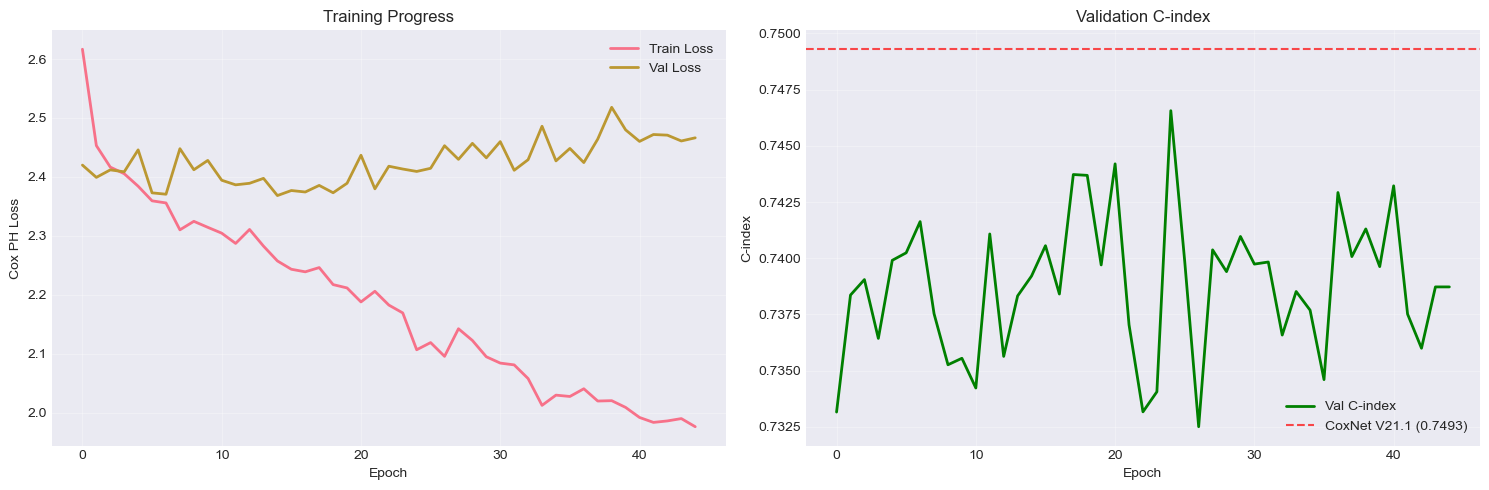

In [10]:
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(15, 5))

ax1.plot(history['train_loss'], label='Train Loss', linewidth=2)
ax1.plot(history['val_loss'], label='Val Loss', linewidth=2)
ax1.set_xlabel('Epoch')
ax1.set_ylabel('Cox PH Loss')
ax1.set_title('Training Progress')
ax1.legend()
ax1.grid(True, alpha=0.3)

ax2.plot(history['val_c_index'], label='Val C-index', linewidth=2, color='green')
ax2.axhline(y=0.7493, color='r', linestyle='--', label='CoxNet V21.1 (0.7493)', alpha=0.7)
ax2.set_xlabel('Epoch')
ax2.set_ylabel('C-index')
ax2.set_title('Validation C-index')
ax2.legend()
ax2.grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

In [11]:
# =============================================================================
# MODEL CONFIGURATION SUMMARY - DeepSurv V20.1
# =============================================================================

print("="*80)
print("MODEL CONFIGURATION SUMMARY - DeepSurv V20.1")
print("="*80)

# === 1. FEATURE ENGINEERING ===
print("\n" + "="*80)
print("1. FEATURE ENGINEERING")
print("="*80)

print(f"\n📊 Total features: {X_train.shape[1]}")
print(f"   Clinical features: {len([c for c in X_train.columns if c in numeric_features or c.startswith('CENTER')])}")
print(f"   Molecular features: {len([c for c in X_train.columns if c.startswith('gene_') or c.startswith('effect_') or c.startswith('vaf_') or c == 'mutation_count_total'])}")
print(f"   Cytogenetic features: {len([c for c in X_train.columns if c.startswith('cyto_')])}")
print(f"   Enriched features: {len([c for c in X_train.columns if '_log' in c or '_sqrt' in c or '_squared' in c or '_ratio' in c or '_x_' in c or 'BLAST_low' in c or 'BLAST_high' in c])}")

print("\n✨ Enriched feature types:")
print(f"   - Non-linear transforms: {len([c for c in X_train.columns if '_log' in c or '_sqrt' in c or '_squared' in c])}")
print(f"   - Clinical ratios: {len([c for c in X_train.columns if '_ratio' in c])}")
print(f"   - Interactions: {len([c for c in X_train.columns if '_x_' in c])}")
print(f"   - Binning: {len([c for c in X_train.columns if 'BLAST_low' in c or 'BLAST_high' in c])}")

print("\n📋 Feature list (first 30):")
for i, feat in enumerate(X_train.columns[:30], 1):
    print(f"   {i:2d}. {feat}")
if X_train.shape[1] > 30:
    print(f"   ... and {X_train.shape[1] - 30} more features")

# === 2. MODEL ARCHITECTURE ===
print("\n" + "="*80)
print("2. MODEL ARCHITECTURE")
print("="*80)

print(f"\n🏗️  Model type: Improved DeepSurv with Residual Connections")
print(f"   Architecture: [256, 128, 64, 32]")
print(f"   Input dimension: {input_dim}")
print(f"   Output dimension: 1 (risk score)")
print(f"   Dropout rate: 0.4")
print(f"   Total parameters: {total_params:,}")
print(f"   Activation: ReLU")
print(f"   Normalization: BatchNorm1d")
print(f"   Skip connections: Yes (ResidualBlocks)")

# === 3. LOSS FUNCTION ===
print("\n" + "="*80)
print("3. LOSS FUNCTION")
print("="*80)

print(f"\n📐 Loss: Cox Proportional Hazards")
print(f"   Type: Negative partial log-likelihood")
print(f"   Handles censoring: Yes")
print(f"   Epsilon for stability: 1e-7")

# === 4. TRAINING HYPERPARAMETERS ===
print("\n" + "="*80)
print("4. TRAINING HYPERPARAMETERS")
print("="*80)

print(f"\n⚙️  Optimizer: Adam")
print(f"   Learning rate: {learning_rate}")
print(f"   Weight decay (L2): {weight_decay}")
print(f"   Batch size: {batch_size}")

print(f"\n🔄 Learning rate scheduler:")
print(f"   Type: ReduceLROnPlateau")
print(f"   Mode: min (reduce when loss plateaus)")
print(f"   Factor: 0.5 (halve LR)")
print(f"   Patience: 7 epochs")

print(f"\n⏱️  Training configuration:")
print(f"   Max epochs: {num_epochs}")
print(f"   Early stopping patience: {patience}")
print(f"   Random seed: 42")

# === 5. DATA SPLIT ===
print("\n" + "="*80)
print("5. DATA SPLIT")
print("="*80)

print(f"\n📦 Dataset sizes:")
print(f"   Total patients: {len(y_surv)}")
print(f"   Train: {X_train.shape[0]} patients ({X_train.shape[0]/len(y_surv)*100:.1f}%)")
print(f"   Validation: {X_val.shape[0]} patients ({X_val.shape[0]/len(y_surv)*100:.1f}%)")
print(f"   Test: {X_scaled_test.shape[0]} patients")

print(f"\n⚖️  Stratification: By OS_STATUS (event/censored)")
print(f"   Events in full dataset: {y_surv['OS_STATUS'].sum()} / {len(y_surv)} ({y_surv['OS_STATUS'].sum()/len(y_surv)*100:.1f}%)")

# === 6. PREPROCESSING ===
print("\n" + "="*80)
print("6. PREPROCESSING")
print("="*80)

print(f"\n🔧 Imputation:")
print(f"   Strategy: median")
print(f"   Library: SimpleImputer (sklearn)")

print(f"\n📊 Scaling:")
print(f"   Method: StandardScaler (z-score normalization)")
print(f"   Library: sklearn")
print(f"   Applied to: All features")

# === 7. PERFORMANCE ===
print("\n" + "="*80)
print("7. PERFORMANCE METRICS")
print("="*80)

print(f"\n🎯 Best validation C-index: {best_val_c_index:.4f}")
print(f"   Training epochs completed: {len(history['val_c_index'])}")
print(f"   Best epoch: {np.argmax(history['val_c_index']) + 1}")

print(f"\n📈 Performance comparison:")
print(f"   RSF V2 baseline:     0.7334")
print(f"   CoxNet V21.1:        0.7493")
print(f"   DeepSurv V20.1:      {best_val_c_index:.4f}")

# === 8. COMPUTATIONAL DETAILS ===
print("\n" + "="*80)
print("8. COMPUTATIONAL DETAILS")
print("="*80)

print(f"\n💻 Device: {device}")
print(f"   CUDA available: {torch.cuda.is_available()}")
print(f"   PyTorch version: {torch.__version__}")

print(f"\n🔢 Batch processing:")
print(f"   Train batches per epoch: {len(train_loader)}")
print(f"   Validation batches: {len(val_loader)}")

print("\n" + "="*80)
print("END OF CONFIGURATION SUMMARY")
print("="*80 + "\n")

MODEL CONFIGURATION SUMMARY - DeepSurv V20.1

1. FEATURE ENGINEERING

📊 Total features: 132
   Clinical features: 28
   Molecular features: 61
   Cytogenetic features: 17
   Enriched features: 27

✨ Enriched feature types:
   - Non-linear transforms: 12
   - Clinical ratios: 4
   - Interactions: 9
   - Binning: 2

📋 Feature list (first 30):
    1. BM_BLAST
    2. WBC
    3. ANC
    4. MONOCYTES
    5. HB
    6. PLT
    7. CENTER_CGM
    8. CENTER_DUS
    9. CENTER_DUTH
   10. CENTER_FLO
   11. CENTER_FUCE
   12. CENTER_GESMD
   13. CENTER_HIAE
   14. CENTER_HMS
   15. CENTER_ICO
   16. CENTER_IHBT
   17. CENTER_KI
   18. CENTER_MSK
   19. CENTER_MUV
   20. CENTER_PV
   21. CENTER_REL
   22. CENTER_RMCN
   23. CENTER_ROM
   24. CENTER_TUD
   25. CENTER_UMG
   26. CENTER_UOB
   27. CENTER_UOXF
   28. CENTER_VU
   29. mutation_count_total
   30. vaf_mean
   ... and 102 more features

2. MODEL ARCHITECTURE

🏗️  Model type: Improved DeepSurv with Residual Connections
   Architecture: [256, 

## 11. Predictions & Submission

In [ ]:
X_test_tensor = torch.FloatTensor(X_scaled_test.values).to(device)

model.eval()
with torch.no_grad():
    test_risk_scores = model(X_test_tensor).cpu().numpy().flatten()

submission = pd.DataFrame({
    'ID': X_scaled_test.index,
    'OS_YEARS': test_risk_scores
})

submission_path = os.path.join(DATA_PATH, "submission_v20.1_deepsurv_improved.csv")
submission.to_csv(submission_path, index=False)

print("="*60)
print("SUBMISSION CREATED")
print("="*60)
print(f"✓ File: {submission_path}")
print(f"\nPreview:")
print(submission.head(10))

## 12. Summary

In [ ]:
print("="*60)
print("SUMMARY - DeepSurv V20.1 (Improved)")
print("="*60)
print(f"\n✨ Improvements vs V20:")
print(f"  - Enriched features (+~40 features)")
print(f"  - Deeper architecture: [256, 128, 64, 32]")
print(f"  - Residual connections")
print(f"  - Optimized hyperparameters")
print(f"  - Smaller batch size (32)")
print(f"\n📊 Performance:")
print(f"  Validation C-index: {best_val_c_index:.4f}")
print(f"\n🏆 Model Comparison:")
print(f"  RSF V2:              0.7334")
print(f"  CoxNet V21.1:        0.7493")
print(f"  DeepSurv V20.1:      {best_val_c_index:.4f}")
print(f"\n🎯 Next Steps:")
print(f"  - Create ensemble (RSF + CoxNet + DeepSurv)")
print(f"  - Expected ensemble C-index: 0.75-0.77+")
print(f"  - Submit best single model or ensemble")
print("="*60)